In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
HERE=Path.cwd().resolve()
ANALYSIS=next((p for p in (HERE,*HERE.parents) if (p/'seacofs_tilt_tools.py').exists()),None)
if ANALYSIS is None: raise FileNotFoundError('Run from seacofs_eddy_tilt_analysis or a subfolder')
WORK=ANALYSIS/'esp_population_composites'
DATASET_SRC=ANALYSIS.parent/'seacofs_eddy_dataset_modular'/'src'
ESP_ROOT=Path('/home/z5297792/ESP_zonodo')
for p in (ANALYSIS,WORK,DATASET_SRC,ESP_ROOT):
    if str(p) not in sys.path: sys.path.insert(0,str(p))
import functions as esp
import seacofs_tilt_tools as tilt
import planetary_composite_tools as pct
import composite_comparison_tools as ccomp
import regional_composite_tools as rct
pd.set_option('display.max_columns',60)


In [2]:
ELLIPSE_FRAC = 1.0
USE_PV_CACHE = True

paths=tilt.Paths()
grid=tilt.load_grid(paths.grid,paths.z_r)
surface,_=tilt.load_tilt_tables(paths,add_regions=True,grid=grid)
surface = tilt.add_pv_gradient_terms(
    surface,
    grid,
    core_mean=True,
    frac=ELLIPSE_FRAC,
    surface_method="esp_gaussian",
    averaging="nonlinear",
    use_max_abs_w=True,
    max_depth_m=1000,
    use_cache=USE_PV_CACHE,
)
# Refresh the established six labels even if PV was loaded from its saved table.
surface=tilt.add_region_labels(surface,grid)
vertical=tilt.load_vert(paths)


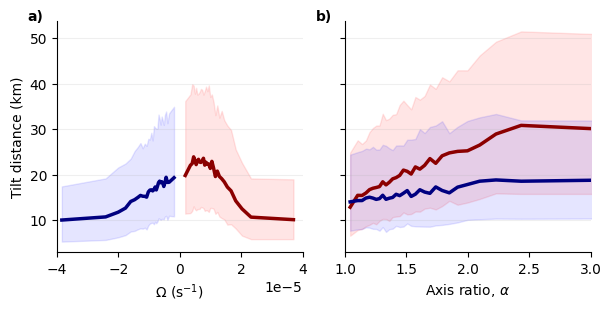

In [3]:
fig, axs = plt.subplots(1, 2, figsize=(6, 3), sharey=True, constrained_layout=True)
axs = axs.ravel()

panels = [
    ("Omega", r"$\Omega$ (s$^{-1}$)", (-4e-5, 4e-5)),
    ("AR", r"Axis ratio, $\alpha$", (1, 3)),
    # ("Nbar", r"$\overline{N}^2$ (s$^{-2}$)", None),
]

for label, ax, (col, xlabel, xlim) in zip("abcdef", axs, panels):
    if col in (['Omega', 'w']):
        for cyc in ['AE', 'CE']:
            tilt.binned_tilt_panel(ax, surface[surface.Cyc==cyc].copy(),
                                   col, xlabel, ylabel="Tilt distance (km)" if label in "ad" else None, xlim=xlim)
    else:
        tilt.binned_tilt_panel(ax, surface, col, xlabel, ylabel="Tilt distance (km)" if label in "ad" else None, xlim=xlim)
    ax.text(-0.12, 1.05, f"{label})", transform=ax.transAxes, fontweight="bold", va="top")
# axs[0].legend(frameon=False)
plt.show()